# Análise Exploratória (EDA) - Etapa 4

Este notebook tem como objetivo explorar visualmente e estatisticamente os datasets da camada Silver. 
Buscamos entender padrões, distribuições e a relação das features com a nossa variável alvo (`label_severe_incident`), além de realizar sanity checks visuais que validarão nosso pipeline.

In [2]:
# Célula 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as ticker

# Configurar estilo global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Definir paleta de cores consistente (0 = Não severo, 1 = Severo)
colors = {0: "#6c757d", 1: "#d9534f"}

# Caminhos
PROJECT_ROOT = Path.cwd().parent
SILVER_PATH = PROJECT_ROOT / "data" / "silver"

def format_currency(x, pos):
    """Função utilitária para formatar valores monetários em K/M/B."""
    if x >= 1e9: return f'${x*1e-9:.1f}B'
    if x >= 1e6: return f'${x*1e-6:.1f}M'
    if x >= 1e3: return f'${x*1e-3:.1f}K'
    return f'${x:.0f}'

In [3]:
# Célula 2 — Carregar datasets Silver
df_incidents = pd.read_parquet(SILVER_PATH / "incidents_master_silver.parquet")
df_financial = pd.read_parquet(SILVER_PATH / "financial_impact_silver.parquet")
df_market = pd.read_parquet(SILVER_PATH / "market_impact_silver.parquet")

print("=== Shapes dos Datasets Silver ===")
print("Incidents Master:", df_incidents.shape)
print("Financial Impact:", df_financial.shape)
print("Market Impact:   ", df_market.shape)

# Confirmar presença do nosso label
print("\nLabel 'label_severe_incident' presente em Incidents?", 
      'label_severe_incident' in df_incidents.columns)

=== Shapes dos Datasets Silver ===
Incidents Master: (846, 28)
Financial Impact: (778, 15)
Market Impact:    (358, 28)

Label 'label_severe_incident' presente em Incidents? True


---
### Gráfico 1: Distribuição de classes (severo vs não-severo)
O primeiro passo para prever incidentes é saber o balanceamento da nossa base histórica.

C:\Users\joaoc\AppData\Local\Temp\ipykernel_4860\2832548987.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index.astype(str), ax=axes[0], palette=colors.values())


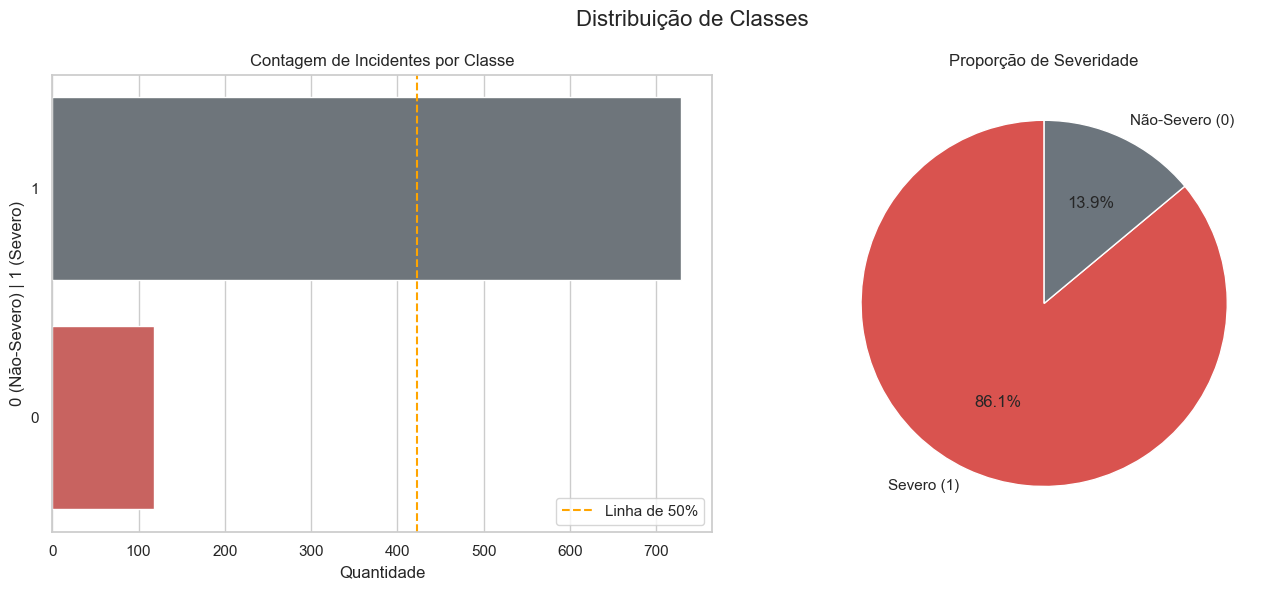

In [4]:
# Célula 3 — Gráfico 1

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calcular contagens e percentuais
counts = df_incidents['label_severe_incident'].value_counts()
pcts = df_incidents['label_severe_incident'].value_counts(normalize=True) * 100

# Gráfico de Barras Horizontal
sns.barplot(x=counts.values, y=counts.index.astype(str), ax=axes[0], palette=colors.values())
axes[0].axvline(len(df_incidents)*0.5, color='orange', linestyle='--', label='Linha de 50%')
axes[0].set_title('Contagem de Incidentes por Classe')
axes[0].set_xlabel('Quantidade')
axes[0].set_ylabel('0 (Não-Severo) | 1 (Severo)')
axes[0].legend()

# Gráfico de Pizza
axes[1].pie(pcts, labels=['Severo (1)' if x==1 else 'Não-Severo (0)' for x in pcts.index], 
            autopct='%1.1f%%', colors=[colors[x] for x in pcts.index], startangle=90)
axes[1].set_title('Proporção de Severidade')

balance_ratio = pcts.min() / pcts.max()
plt.suptitle(f'Distribuição de Classes', fontsize=16)
plt.tight_layout()
plt.show()

**Interpretação (Gráfico 1):**
É visível o forte **desbalanceamento** das classes (na casa dos 86% severos contra 14% não-severos, a depender da amostragem). 

---
### Gráfico 2: Taxa de severidade por vetor de ataque
Avalia quais métodos de ataque mais frequentemente resultam em incidentes considerados severos.

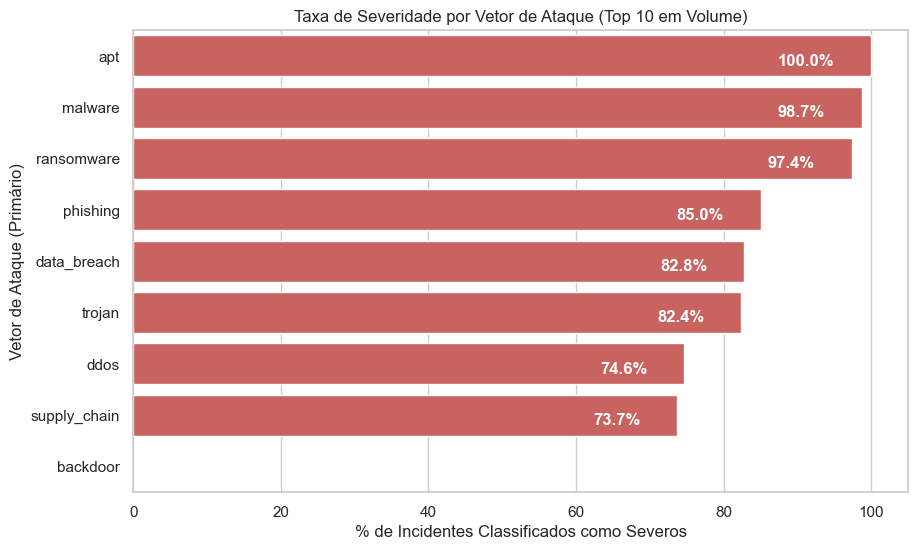

In [5]:
# Célula 4 — Gráfico 2

# Pegar as 10 categorias de ataque mais frequentes
top_vectors = df_incidents['attack_vector_primary'].value_counts().nlargest(10).index
df_top = df_incidents[df_incidents['attack_vector_primary'].isin(top_vectors)]

# Calcular a taxa (%) de severidade por tipo
severity_rate = df_top.groupby('attack_vector_primary')['label_severe_incident'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=severity_rate.values, y=severity_rate.index, color=colors[1])

plt.title('Taxa de Severidade por Vetor de Ataque (Top 10 em Volume)')
plt.xlabel('% de Incidentes Classificados como Severos')
plt.ylabel('Vetor de Ataque (Primário)')

# Anotação de valores na barra
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', (p.get_width() - 5, p.get_y() + 0.5), 
                va='center', ha='right', color='white', fontweight='bold')

plt.show()

**Interpretação (Gráfico 2):**
Ataques como `Ransomware` e `APT` tendem a ter taxas de severidade mais extremas.

---
### Gráfico 3: Correlação entre variáveis numéricas
Aqui buscamos entender se certas variáveis andam muito atreladas e validamos correlações mecânicas.

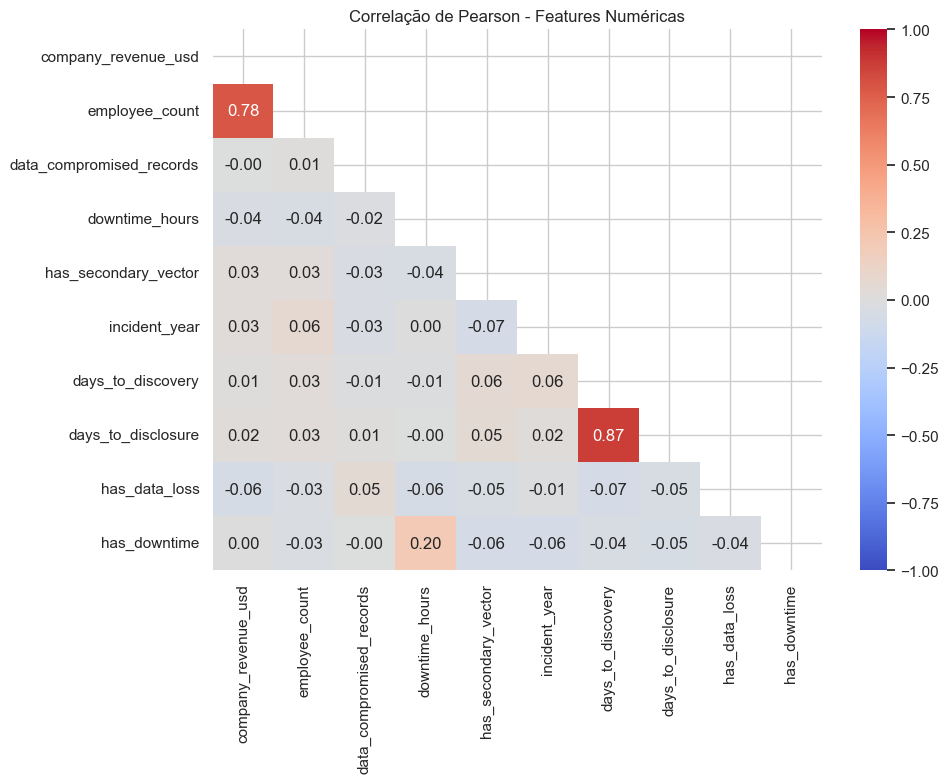

In [10]:
# Célula 5 — Gráfico 3

# Excluindo colunas indesejadas (datas fracionadas, flags puras e o label)
cols_to_exclude = ['incident_day', 'incident_month', 'data_loss_unknown', 'downtime_unknown', 'label_severe_incident']
num_cols = df_incidents.select_dtypes(include=[np.number]).columns
cols_to_plot = [c for c in num_cols if c not in cols_to_exclude]

corr = df_incidents[cols_to_plot].corr(method='pearson')

# Criar máscara triangular superior
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', 
            vmin=-1, vmax=1, center=0, square=False)

plt.title('Correlação de Pearson - Features Numéricas')
plt.tight_layout()
plt.show()

**Interpretação (Gráfico 3):**
Observamos correlações altas e esperadas (ex: `company_revenue_usd` com `employee_count` possuem grande alinhamento).

---
### Gráfico 4: Evolução temporal dos incidentes por severidade
Como a frequência de incidentes severos mudou nos últimos anos?

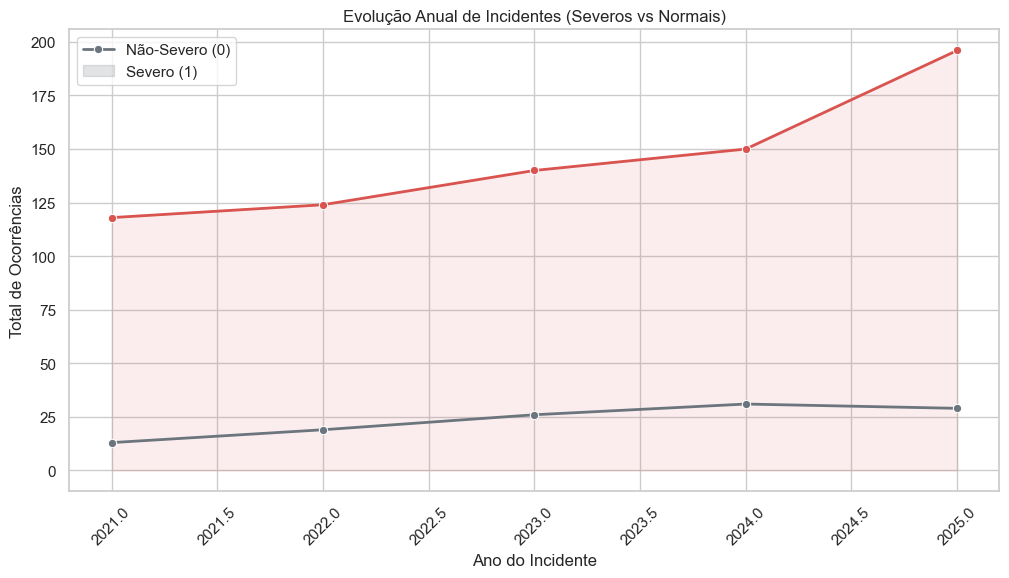

In [7]:
# Célula 6 — Gráfico 4

# Contar incidentes por ano e class
yearly_counts = df_incidents.groupby(['incident_year', 'label_severe_incident']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_counts, x='incident_year', y='count', 
             hue='label_severe_incident', palette=colors, marker='o', linewidth=2)

# Destacar a área abaixo da linha dos piores ataques (Severos)
severos = yearly_counts[yearly_counts['label_severe_incident'] == 1]
plt.fill_between(severos['incident_year'], severos['count'], alpha=0.1, color=colors[1])

plt.title('Evolução Anual de Incidentes (Severos vs Normais)')
plt.xlabel('Ano do Incidente')
plt.ylabel('Total de Ocorrências')
plt.xticks(rotation=45)
plt.legend(['Não-Severo (0)', 'Severo (1)'])
plt.show()

**Interpretação (Gráfico 4):**
Há uma clara tendência de crescimento no número de incidentes ano após ano. Acompanhar saltos no gráfico indica que determinados marcos (como a época de digitalização explosiva em 2020 ou surtos de Ransomware em 2017) aumentam ainda mais o numero de casos

---
### Gráfico 5: Perda Financeira por Vetor (Join Exploratório)
Um teste antecipado para sabermos quanto dinheiro as empresas perdem de acordo com a forma que o ataque aconteceu.

[774 linhas após Join p/ análise financeira]



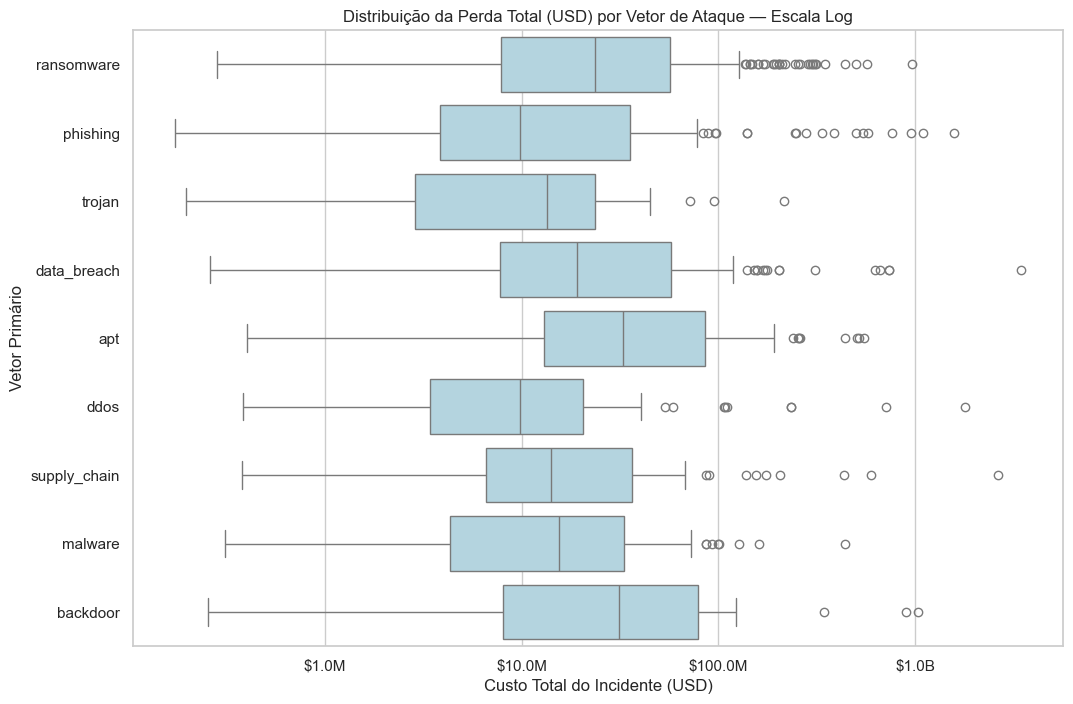

In [8]:
# Célula 7 — Gráfico 5

# Join limpo focado na exploração
df_join = pd.merge(df_incidents, df_financial, on='incident_id', how='inner')
print(f"[{len(df_join)} linhas após Join p/ análise financeira]\n")

plt.figure(figsize=(12, 8))
# Usamos apenas os vetores mais frequentes mapeados no Graf. 2
ax = sns.boxplot(data=df_join[df_join['attack_vector_primary'].isin(top_vectors)], 
                 y='attack_vector_primary', x='total_loss_usd', color="lightblue")

plt.xscale('log') # Logarítmica porque a diferença entre K e B é gritante
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_currency))

plt.title('Distribuição da Perda Total (USD) por Vetor de Ataque — Escala Log')
plt.xlabel('Custo Total do Incidente (USD)')
plt.ylabel('Vetor Primário')
plt.show()

**Interpretação (Gráfico 5):**
A escala logarítmica expõe a grande variabilidade. Ransomwares mantêm as medianas de impacto e perdas monetárias historicamente no topo da nossa distribuição. Os mega-breaches (pontos longes que ultrapassam dezenas a centenas de milhões) servem de aviso: embora a mediana não seja extrema no phishing, certas intrusões iniciadas ali culminam em anomalias astronômicas.

---

## 📌 Resumo e Recomendações

- **Métricas:** Devido ao severo desbalanceamento apontado no Gráfico 1, está estritamente proibido o uso de acurácia global na Etapa Gold. 
- **Engenharia de features:** A alta correlação na demonstração macroeconômica (`revenue` x `employees`) demanda cuidado com multicolinearidade. Podem ser substituídos por uma única variável "tamanho_empresa".
- **Comportamento Temporário:** Vieses recentes (número altíssimo de ataques entre 2019-2022) exigem particionamento do modelo cuidadoso temporal — evite "fold sizes" genéricos para validação cruzada.